In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install opencv-python tqdm

In [3]:
import cv2
import os
import shutil
from tqdm import tqdm

In [4]:
import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/final-year-research"
WORK_DIR = "/content/final-year-research/dataset"
ZIP_PATH = f"{PROJECT_DIR}/dataset/WilderPerson.zip"

os.makedirs(WORK_DIR, exist_ok=True)
shutil.copy(ZIP_PATH, f"{WORK_DIR}/WilderPerson.zip")
print("Copied zip to Colab VM")

Copied zip to Colab VM


In [5]:
import zipfile

with zipfile.ZipFile(f"{WORK_DIR}/WilderPerson.zip", 'r') as zip_ref:
    zip_ref.extractall(f"{WORK_DIR}/dataset")

print("Unzipped dataset")

Unzipped dataset


In [6]:
!ls /content/final-year-research/dataset/

dataset  WilderPerson.zip


In [34]:
ORIGINAL_DATASET = "/content/final-year-research/dataset/dataset"
MASK_DATASET = "/content/final-year-research/dataset/final-year-research_face_mask_WilderPerson"

splits = ["train", "valid"]

# how much of the top part of each pedestrian box to mask
HEAD_RATIO = 0.40   # 30% of person height

# mask color: black
MASK_COLOR = (0, 0, 0)

In [35]:
import os

ORIGINAL_DATASET = "/content/final-year-research/dataset/dataset"
splits = ["train", "valid"]

for split in splits:
    print(split)
    print("images exists:", os.path.exists(os.path.join(ORIGINAL_DATASET, split, "images")))
    print("labels exists:", os.path.exists(os.path.join(ORIGINAL_DATASET, split, "labels")))
    print("-" * 30)

train
images exists: True
labels exists: True
------------------------------
valid
images exists: True
labels exists: True
------------------------------


In [36]:
for split in splits:
    src_labels = os.path.join(ORIGINAL_DATASET, split, "labels")
    dst_labels = os.path.join(MASK_DATASET, split, "labels")

    os.makedirs(dst_labels, exist_ok=True)

    for file in os.listdir(src_labels):
        shutil.copy(
            os.path.join(src_labels, file),
            os.path.join(dst_labels, file)
        )

print("Labels copied.")

Labels copied.


In [17]:
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)


In [18]:
def yolo_to_xyxy(label_line, img_w, img_h):
    cls, x, y, w, h = map(float, label_line.split())

    x *= img_w
    y *= img_h
    w *= img_w
    h *= img_h

    x1 = int(x - w / 2)
    y1 = int(y - h / 2)
    x2 = int(x + w / 2)
    y2 = int(y + h / 2)

    # clip to image boundaries
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)

    return int(cls), x1, y1, x2, y2

Face Detection masking

In [19]:
for split in splits:
    src_images = os.path.join(ORIGINAL_DATASET, split, "images")
    src_labels = os.path.join(ORIGINAL_DATASET, split, "labels")
    dst_images = os.path.join(MASK_DATASET, split, "images")

    os.makedirs(dst_images, exist_ok=True)

    for img_name in tqdm(os.listdir(src_images), desc=f"Processing {split}"):

        img_path = os.path.join(src_images, img_name)
        label_path = os.path.join(src_labels, img_name.replace(".jpg", ".txt"))

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_h, img_w = img.shape[:2]

        # if no label file, save original image
        if not os.path.exists(label_path):
            cv2.imwrite(os.path.join(dst_images, img_name), img)
            continue

        with open(label_path, "r") as f:
            labels = f.readlines()

        for line in labels:
            cls, x1, y1, x2, y2 = yolo_to_xyxy(line, img_w, img_h)

            # only process pedestrian class
            if cls != 0:
                continue

            roi = img[y1:y2, x1:x2]
            if roi.size == 0:
                continue

            gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
            faces = face_detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)

            for (fx, fy, fw, fh) in faces:
                # convert face coordinates back to full-image coordinates
                abs_x1 = x1 + fx
                abs_y1 = y1 + fy
                abs_x2 = x1 + fx + fw
                abs_y2 = y1 + fy + fh

                # black mask
                img[abs_y1:abs_y2, abs_x1:abs_x2] = (0, 0, 0)

        cv2.imwrite(os.path.join(dst_images, img_name), img)

print("Masked dataset created successfully")

Processing valid: 100%|██████████| 3284/3284 [00:21<00:00, 153.44it/s]

Masked dataset created successfully


Masking using dataset upeer section

In [37]:
# YOLO label -> pixel box
# ---------------------------------
def yolo_to_xyxy(label_line, img_w, img_h):
    cls, x, y, w, h = map(float, label_line.split())

    x *= img_w
    y *= img_h
    w *= img_w
    h *= img_h

    x1 = int(x - w / 2)
    y1 = int(y - h / 2)
    x2 = int(x + w / 2)
    y2 = int(y + h / 2)

    # clip to image boundaries
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)

    return int(cls), x1, y1, x2, y2

# ---------------------------------
# Create upper-head masked images
# ---------------------------------
for split in splits:
    src_images = os.path.join(ORIGINAL_DATASET, split, "images")
    src_labels = os.path.join(ORIGINAL_DATASET, split, "labels")
    dst_images = os.path.join(MASK_DATASET, split, "images")

    os.makedirs(dst_images, exist_ok=True)

    for img_name in tqdm(os.listdir(src_images), desc=f"Processing {split}"):
        img_path = os.path.join(src_images, img_name)
        label_path = os.path.join(src_labels, img_name.replace(".jpg", ".txt"))

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_h, img_w = img.shape[:2]

        # if no label file, save original image
        if not os.path.exists(label_path):
            cv2.imwrite(os.path.join(dst_images, img_name), img)
            continue

        with open(label_path, "r") as f:
            labels = f.readlines()

        for line in labels:
            cls, x1, y1, x2, y2 = yolo_to_xyxy(line, img_w, img_h)

            # only process pedestrian class
            if cls != 0:
                continue

            person_h = y2 - y1
            if person_h <= 0:
                continue

            head_y2 = y1 + int(person_h * HEAD_RATIO)

            # apply upper-head mask
            img[y1:head_y2, x1:x2] = MASK_COLOR

        cv2.imwrite(os.path.join(dst_images, img_name), img)

print("Upper-head masked dataset created successfully")

Processing valid: 100%|██████████| 3284/3284 [00:14<00:00, 222.80it/s]

Upper-head masked dataset created successfully


In [38]:
for split in splits:
    img_count = len(os.listdir(os.path.join(MASK_DATASET, split, "images")))
    label_count = len(os.listdir(os.path.join(MASK_DATASET, split, "labels")))
    print(split, "images:", img_count, "labels:", label_count)

train images: 10098 labels: 10098
valid images: 3284 labels: 3284


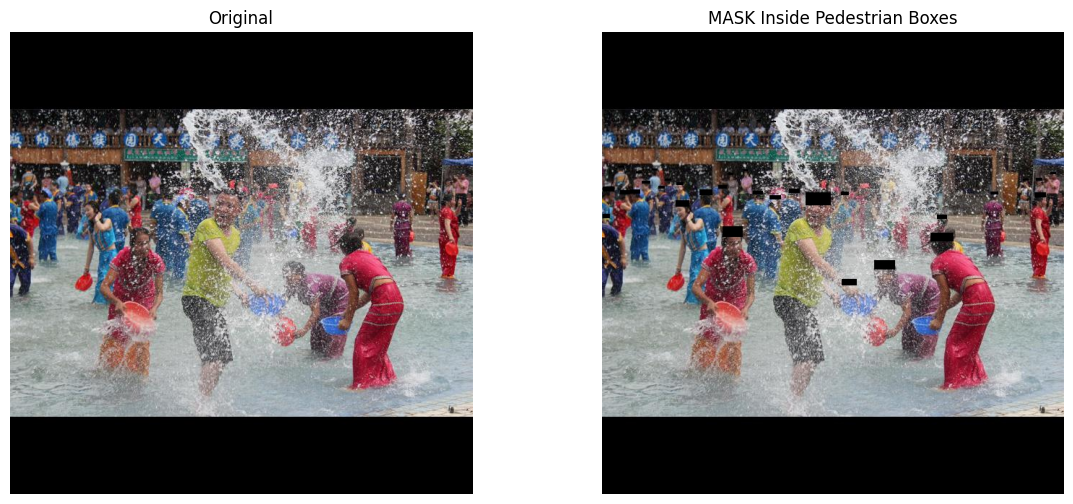

In [39]:
import matplotlib.pyplot as plt

import random

split = "train"
sample_img = random.choice(os.listdir(os.path.join(ORIGINAL_DATASET, split, "images")))

orig_path = os.path.join(ORIGINAL_DATASET, split, "images", sample_img)
blur_path = os.path.join(MASK_DATASET, split, "images", sample_img)

orig = cv2.cvtColor(cv2.imread(orig_path), cv2.COLOR_BGR2RGB)
blur = cv2.cvtColor(cv2.imread(blur_path), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blur)
plt.title("MASK Inside Pedestrian Boxes")
plt.axis("off")

plt.show()

Save the dataset

In [ ]:
import shutil
import os

SRC = "/content/final-year-research/dataset/final-year-research_face_mask_WilderPerson"
DST = "/content/drive/MyDrive/final-year-research/datasets/face_mask_dataset"

# remove old version if it exists
if os.path.exists(DST):
    shutil.rmtree(DST)

shutil.copytree(SRC, DST)

print("Blur dataset saved to Google Drive:", DST)